In [1]:
from utils.experiment_utils import get_all_experiments_info, load_best_model
import torch
import os
import hydra
from omegaconf import DictConfig, OmegaConf

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

import ot

from datasets.lineage_tracing import LTSeqDataset

from geomloss import SamplesLoss

from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [11]:
pretty_palette = ["#1b718c",
          "#cb4f70",
          "#779e1a",
          "#f49044",
          "#9678b6"]

In [2]:
lts = LTSeqDataset(seed=42)

loading cached adata from ./data/processed/adata_pca_50.h5ad  !!
loading cached clone sets from ./data/processed!
splitting 1218 clones into 609 train and 609 test


In [3]:
configs = get_all_experiments_info('/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/', False)

cfgs = [c for c in configs if 'lts' in c['name']]

cfgs

[{'name': 'lts_70643ee733d7dacdc6254c59a37920b5',
  'dir': '/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/lts_70643ee733d7dacdc6254c59a37920b5',
  'config': {'dataset': {'_target_': 'datasets.lineage_tracing.LTSeqDataset', 'set_size': 100, 'min_cells': 3, 'data_shape': [50], 'root': '/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/data', 'seed': '${seed}'}, 'encoder': {'_target_': 'encoder.encoders.DistributionEncoderGNN', 'in_dim': '${dataset.data_shape[0]}', 'latent_dim': '${experiment.latent_dim}', 'hidden_dim': '${experiment.hidden_dim}', 'set_size': '${experiment.set_size}', 'layers': 2, 'fc_layers': 2}, 'model': {'_target_': 'layers.MLP', 'in_dims': [50, 128, 128, 128], 'hidden_dim': 512, 'out_dim': 50, 'layers': 4}, 'coupling': {'_target_': 'types.NoneType'}, 'generator': {'_target_': 'generator.energy.EnergyGenerator', 'model': '${model}', 'noise_dim': '${experiment.latent_dim}', 'sigma_min': 1.0, 'm': 8, 'lambda_energy': 1.0}, 'optimizer': {'_ta

In [4]:
def load_model(cfg, path, device):
    enc = hydra.utils.instantiate(cfg['encoder'])
    gen = hydra.utils.instantiate(cfg['generator'])
    state = load_best_model(path)
    enc.load_state_dict(state['encoder_state_dict'])
    gen.load_state_dict(state['generator_state_dict'])
    enc.eval()
    gen.eval()
    enc.to(device)
    gen.to(device)
    return enc, gen

enc_unst, gen_unst = load_model(cfgs[1]['config'], cfgs[1]['dir'], 'cuda')
enc, gen = load_model(cfgs[0]['config'], cfgs[0]['dir'], 'cuda')

In [24]:
with torch.no_grad():
    z_x_unst_train = enc_unst(lts.train_srcs.cuda())
    z_y_unst_train = enc_unst(lts.train_tgts.cuda())
    z_x_st_train = enc(lts.train_srcs.cuda())
    z_y_st_train = enc(lts.train_tgts.cuda())

    z_x_unst_test = enc_unst(lts.test_srcs.cuda())
    z_y_unst_test = enc_unst(lts.test_tgts.cuda())
    z_x_st_test = enc(lts.test_srcs.cuda())
    z_y_st_test = enc(lts.test_tgts.cuda())

In [25]:
# # 1) get numpy embeddings and torch samples
# X = z_x_st.cpu().numpy()
# Y = z_y_st.cpu().numpy()
# src = lts.train_srcs      # torch.Tensor of shape
# tgt = lts.train_tgts      # torch.Tensor of shape

# # 2) split indices
# n = X.shape[0]
# idx = np.arange(n)
# train_idx, test_idx = train_test_split(idx, test_size=0.5, random_state=42)

# X_train, Y_train = X[train_idx], Y[train_idx]
# X_test,  Y_test  = X[test_idx],  Y[test_idx]

# src_test = src[test_idx]
# z_x_test = z_x_st[test_idx]
# tgt_test = tgt[test_idx]

X_train = z_x_st_train.cpu().numpy()
Y_train = z_y_st_train.cpu().numpy()

X_test = z_x_st_test.cpu().numpy()
Y_test = z_y_st_test.cpu().numpy()

src_test = lts.test_srcs
z_x_test = z_x_st_test
tgt_test = lts.test_tgts

# 3) fit ridge on train
alphas = np.logspace(-6, 6, 25)
ridge = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge.fit(X_train, Y_train)
print("best alpha:", ridge.alpha_)

# 4) eval on test
Y_pred_test = ridge.predict(X_test)
print("Test MSE:", mean_squared_error(Y_test, Y_pred_test))
print("Test R2:",  r2_score(Y_test, Y_pred_test, multioutput='variance_weighted'))

# 5) generate held‐out y_hat and compute EMD
y_hat_test_st = gen(
    src_test.cuda().reshape(-1, 50),
    z_x_test.cuda(),
    torch.tensor(Y_pred_test).cuda()
).reshape(tgt_test.shape)

loss = SamplesLoss("energy")

energies = loss(y_hat_test_st.cuda(), tgt_test.cuda())

energy = energies.mean()

sem = energies.std() / np.sqrt(energies.shape[0])

print('Energy distance on held-out test:', energy.item())
print('SEM on held-out test:', sem.item())

best alpha: 0.31622776601683794
Test MSE: 0.003450004616752267
Test R2: 0.3606579303741455
Energy distance on held-out test: 3.430821180343628
SEM on held-out test: 0.09671928733587265


In [28]:
print(len(lts.test_srcs))

628


In [26]:
# # 1) get numpy embeddings and torch samples
# X = z_x_unst.cpu().numpy()
# Y = z_y_unst.cpu().numpy()
# src = lts.train_srcs      # torch.Tensor of shape
# tgt = lts.train_tgts      # torch.Tensor of shape

# # 2) split indices
# n = X.shape[0]
# idx = np.arange(n)
# train_idx, test_idx = train_test_split(idx, test_size=0.5, random_state=42)

# X_train, Y_train = X[train_idx], Y[train_idx]
# X_test,  Y_test  = X[test_idx],  Y[test_idx]

# src_test = src[test_idx]
# z_x_test = z_x_unst[test_idx]
# tgt_test = tgt[test_idx]

X_train = z_x_unst_train.cpu().numpy()
Y_train = z_y_unst_train.cpu().numpy()

X_test = z_x_unst_test.cpu().numpy()
Y_test = z_y_unst_test.cpu().numpy()

src_test = lts.test_srcs
z_x_test = z_x_unst_test
tgt_test = lts.test_tgts

# 3) fit ridge on train
alphas = np.logspace(-6, 6, 25)
ridge = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge.fit(X_train, Y_train)
print("best alpha:", ridge.alpha_)

# 4) eval on test
Y_pred_test = ridge.predict(X_test)
print("Test MSE:", mean_squared_error(Y_test, Y_pred_test))
print("Test R2:",  r2_score(Y_test, Y_pred_test, multioutput='variance_weighted'))

# 5) generate held‐out y_hat and compute EMD
y_hat_test_unst = gen_unst(
    src_test.cuda().reshape(-1, 50),
    z_x_test.cuda(),
    torch.tensor(Y_pred_test).cuda()
).reshape(tgt_test.shape)

loss = SamplesLoss("energy")

energies_unst = loss(y_hat_test_unst.cuda(), tgt_test.cuda())

energy = energies_unst.mean()

# sem
sem = energies_unst.std() / np.sqrt(energies_unst.shape[0])

print('Energy distance on held-out test:', energy.item())
print('SEM on held-out test:', sem.item())

best alpha: 0.31622776601683794
Test MSE: 0.0020781289786100388
Test R2: 0.41301047801971436
Energy distance on held-out test: 3.1650807857513428
SEM on held-out test: 0.09286073595285416


In [8]:
# times = [lts.test_src_meta[test_idx[i]][1] for i in range(len(test_idx))]

# sns.kdeplot(x=energies.cpu().numpy(), hue=times, common_norm=False,
#             clip=(0, None), palette=pretty_palette, fill=True)

tensor(4.9067, device='cuda:0')
tensor(8.4093, device='cuda:0')
Clone: 3076, Time: 4
Clone: 3076, Time: 4


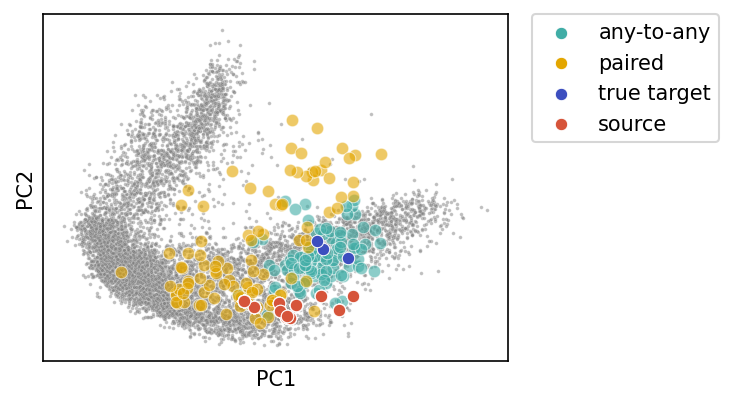

tensor(8.3467, device='cuda:0')
tensor(11.6380, device='cuda:0')
Clone: 29, Time: 4
Clone: 29, Time: 4


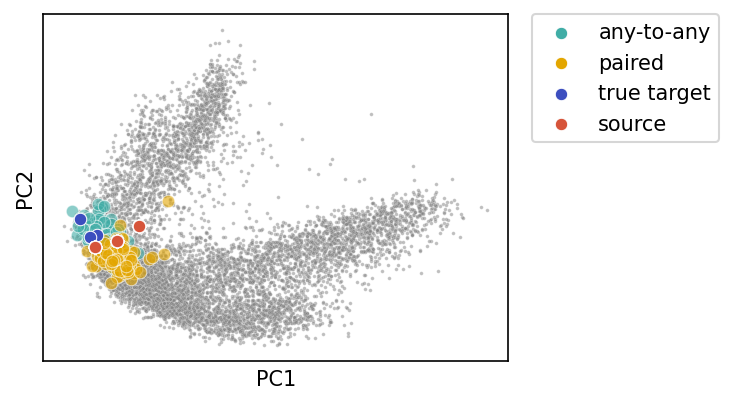

tensor(5.8945, device='cuda:0')
tensor(10.1302, device='cuda:0')
Clone: 1074, Time: 2
Clone: 1074, Time: 2


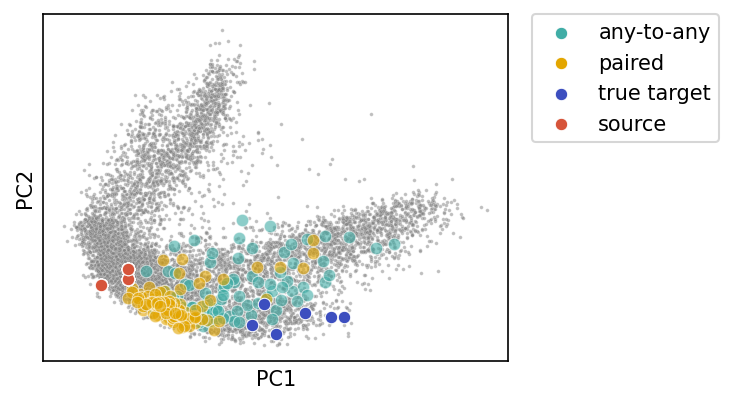

tensor(1.2996, device='cuda:0')
tensor(4.4603, device='cuda:0')
Clone: 3384, Time: 4
Clone: 3384, Time: 4


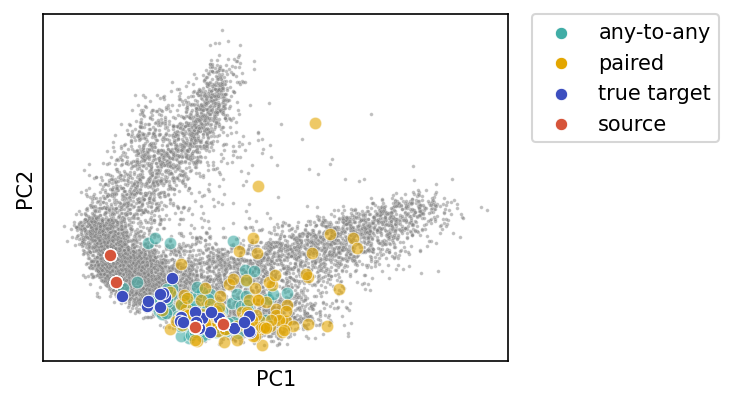

tensor(3.2529, device='cuda:0')
tensor(9.7386, device='cuda:0')
Clone: 4101, Time: 4
Clone: 4101, Time: 4


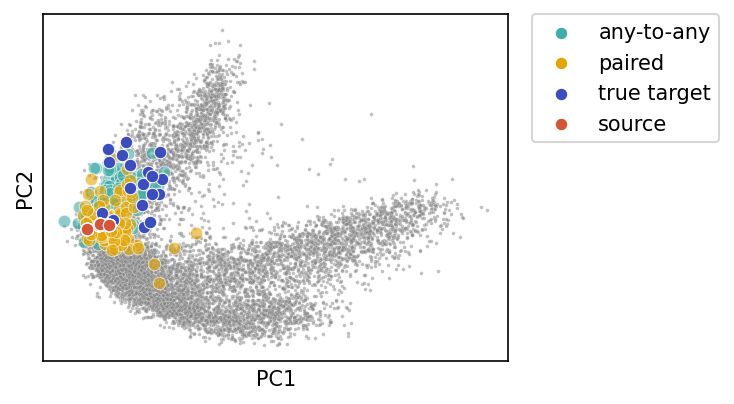

In [9]:
from sklearn.neighbors import NearestNeighbors

# nbrs = NearestNeighbors(n_neighbors=2).fit(lts.adata.obsm['X_pca'][:, :2])

to_plot = lts.adata[np.random.choice(lts.adata.shape[0], 10000, replace=False)]

for i in range(252):#np.random.choice(252, 10, replace=False):


    metadata = lts.test_src_meta[test_idx[i]]
    clone = int(metadata[0])
    time = int(float(metadata[1]))

    if energies[i] - energies_unst[i] > 3:# and time < 4:

        print(energies_unst[i])
        print(energies[i])

        true_targets = lts.adata[lts.adata.obs['clone'] == clone]
        true_targets = true_targets[true_targets.obs['time'] == time + 2]

        predicted_pcs_unst = y_hat_test_unst[i].cpu().numpy()
        predicted_pcs_st = y_hat_test_st[i].cpu().numpy()

        # print(len(predicted_pcs))

        # distances, indices = nbrs.kneighbors(predicted_pcs[:, :2])
        # neighbors = lts.adata[indices[0]]

        print(f'Clone: {clone}, Time: {time}')

        print(f'Clone: {clone}, Time: {time}')

        plt.figure(figsize=(4, 3), dpi=150)


        sns.scatterplot(x=to_plot.obsm['X_pca'][:, 0],
                        y=to_plot.obsm['X_pca'][:, 1],
                        color='gray', alpha=0.5, s=3)
        
        sns.scatterplot(x=predicted_pcs_unst[:, 0],
                        y=predicted_pcs_unst[:, 1], alpha=0.6,
                        color='#40ada6', label='any-to-any')

        sns.scatterplot(x=predicted_pcs_st[:, 0],
                        y=predicted_pcs_st[:, 1], alpha=0.6,
                        color='#e3a600', label='paired')
        
        sns.scatterplot(x=true_targets.obsm['X_pca'][:, 0],
                        y=true_targets.obsm['X_pca'][:, 1],
                        color='#3c4ebf', label='true target')
        
        sns.scatterplot(x=src_test.cpu().numpy()[i, :, 0],
                        y=src_test.cpu().numpy()[i, :, 1],
                        color='#d6543a', label='source')

        
        leg = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
                    borderaxespad=0., markerscale=1, )
        for lh in leg.legend_handles: 
            lh.set_alpha(1)

        plt.xticks([])
        plt.yticks([])
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.show()


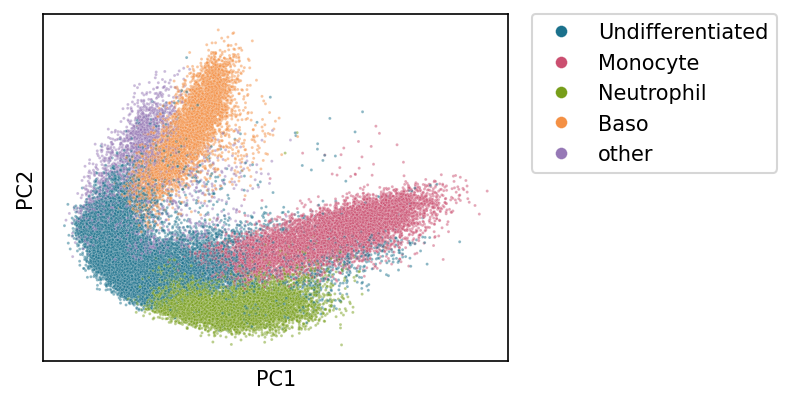

In [12]:
# if type count is less than 5k, reassign type to 'other'

counts = lts.adata.obs['type'].value_counts()
lts.adata.obs['type'] = lts.adata.obs['type'].apply(lambda x: x if counts[x] >= 5000 else 'other')

plt.figure(figsize=(4, 3), dpi=150)

sns.scatterplot(x=lts.adata.obsm['X_pca'][:, 0],
                y=lts.adata.obsm['X_pca'][:, 1],
                hue=lts.adata.obs['type'], s=2, 
                alpha=0.5, palette=pretty_palette)

# legend to side, with marker sizes 10 and transparency 1
leg = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
              borderaxespad=0., markerscale=4, )
for lh in leg.legend_handles: 
    lh.set_alpha(1)

plt.xticks([])
plt.yticks([])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [12]:
lts.n_sets

4830